### Imports

#### Import data utils

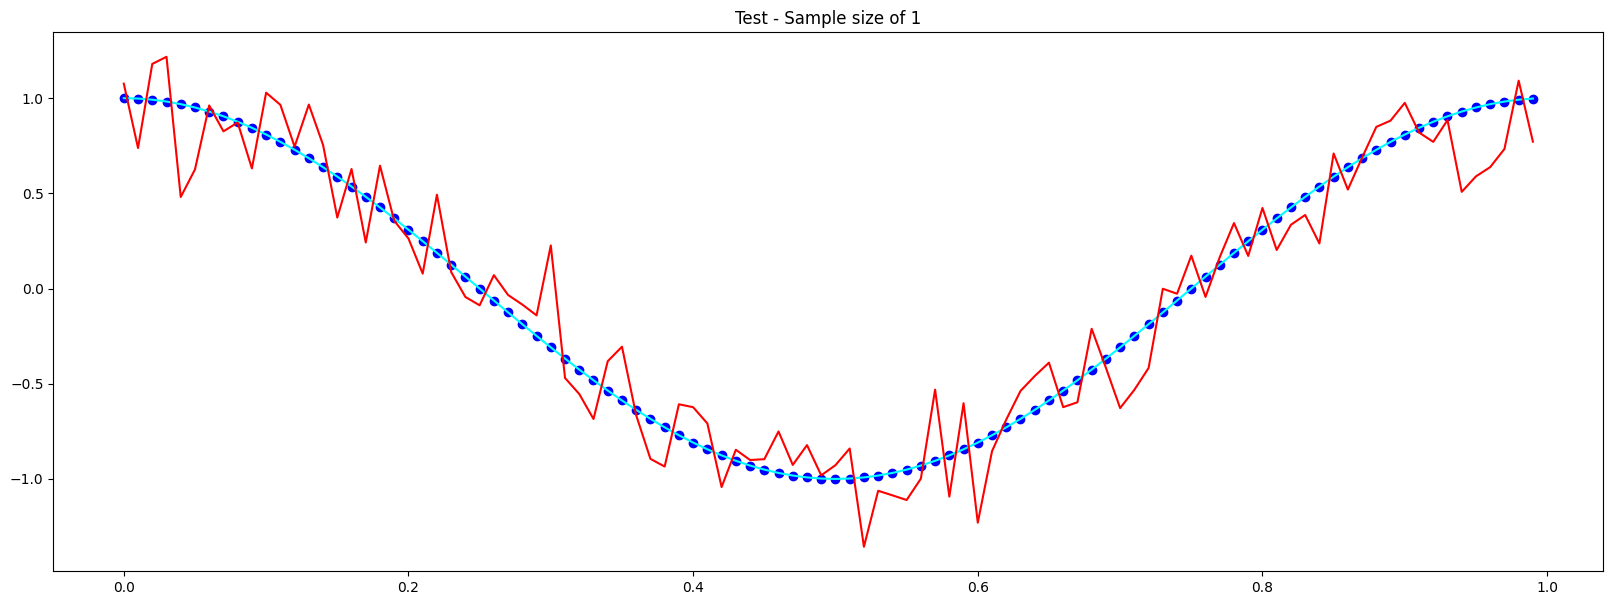

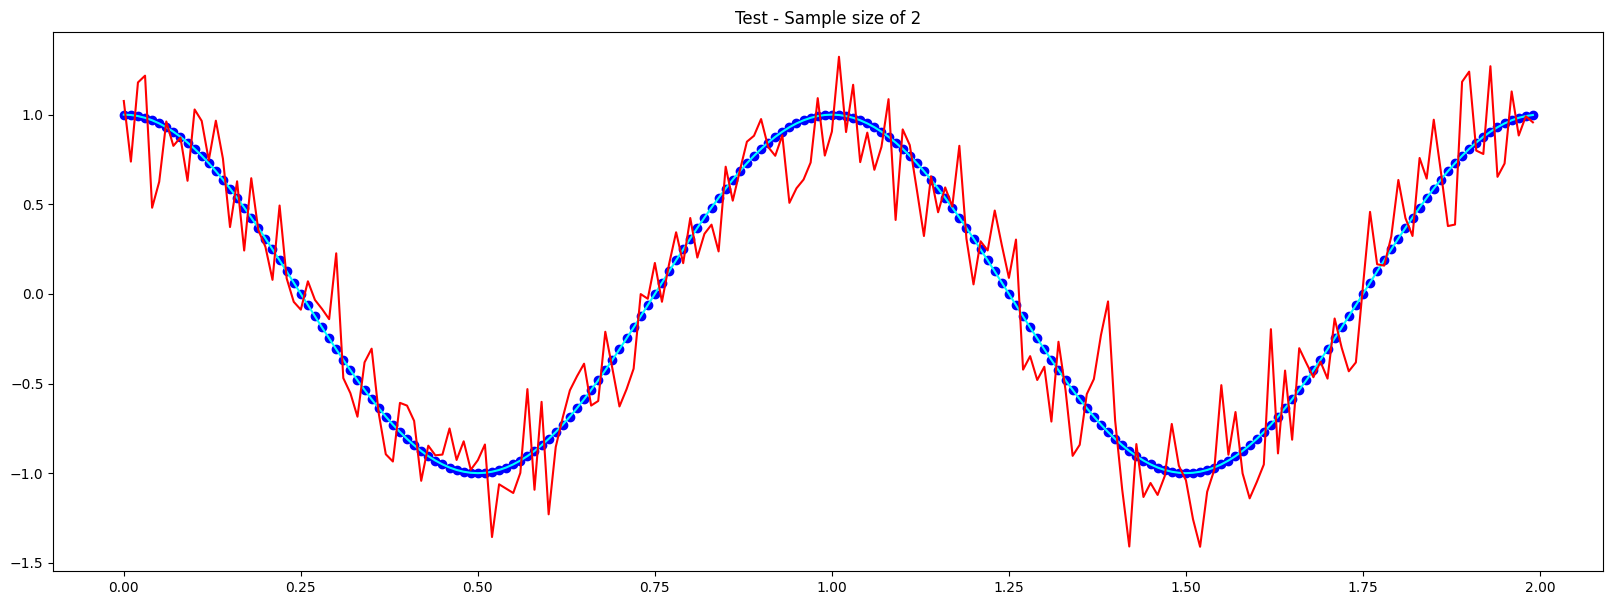

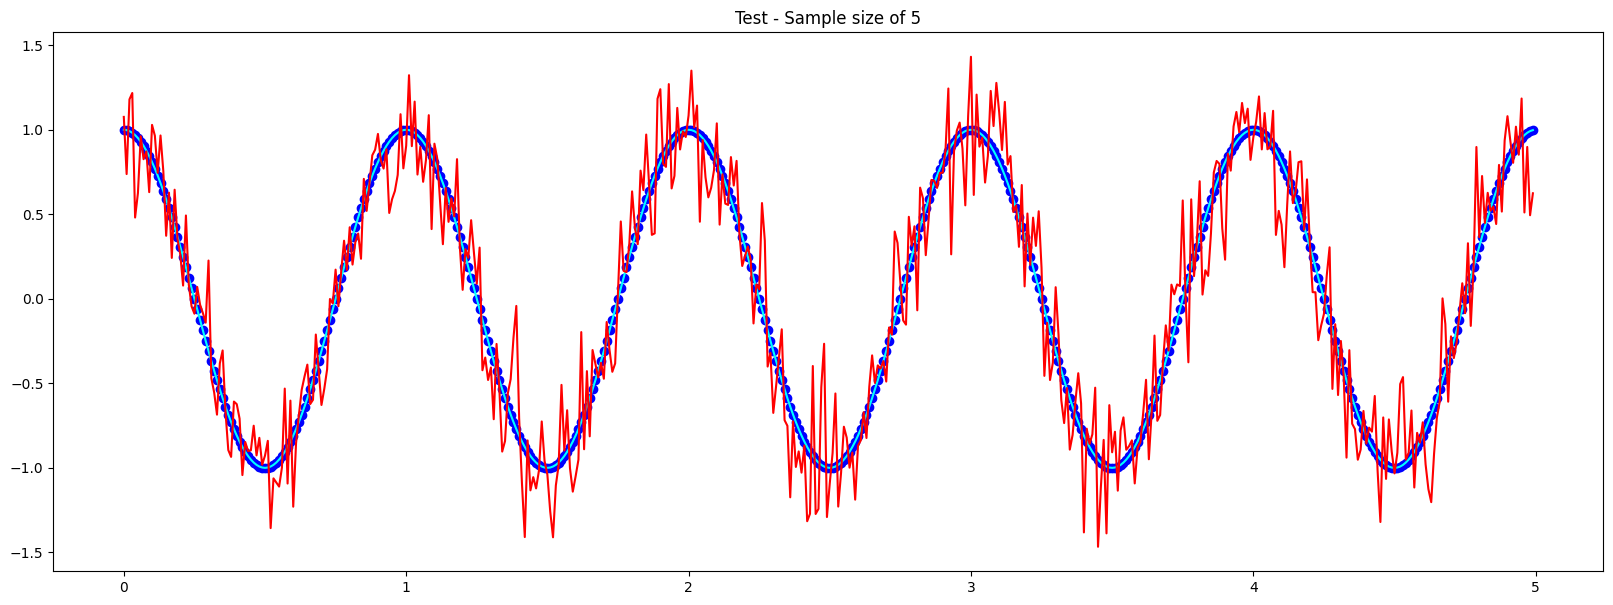

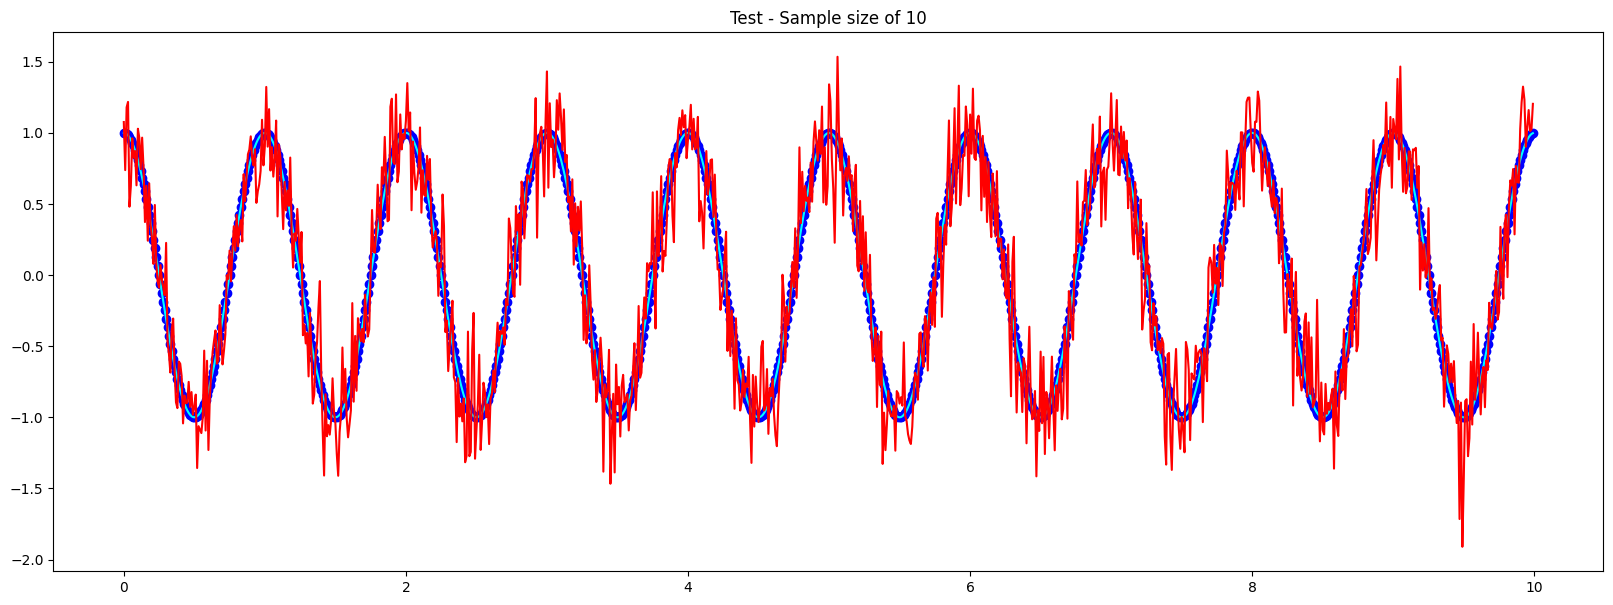

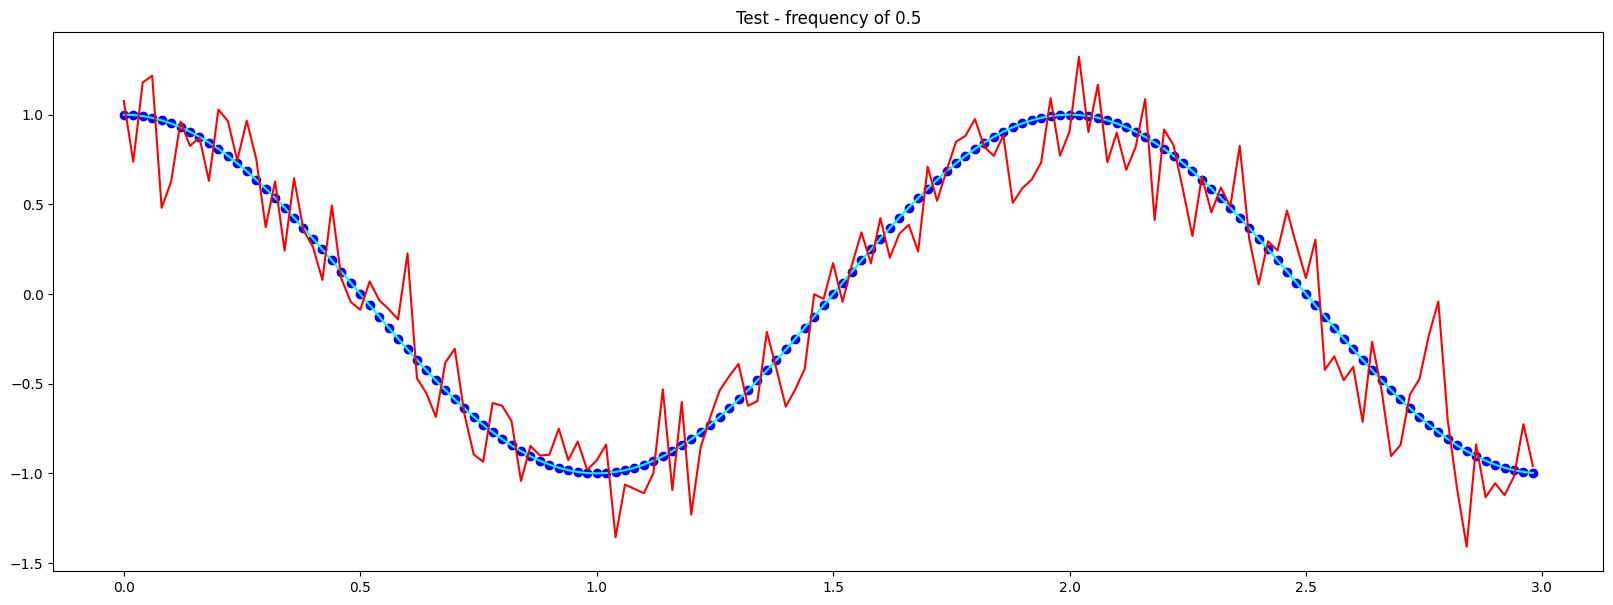

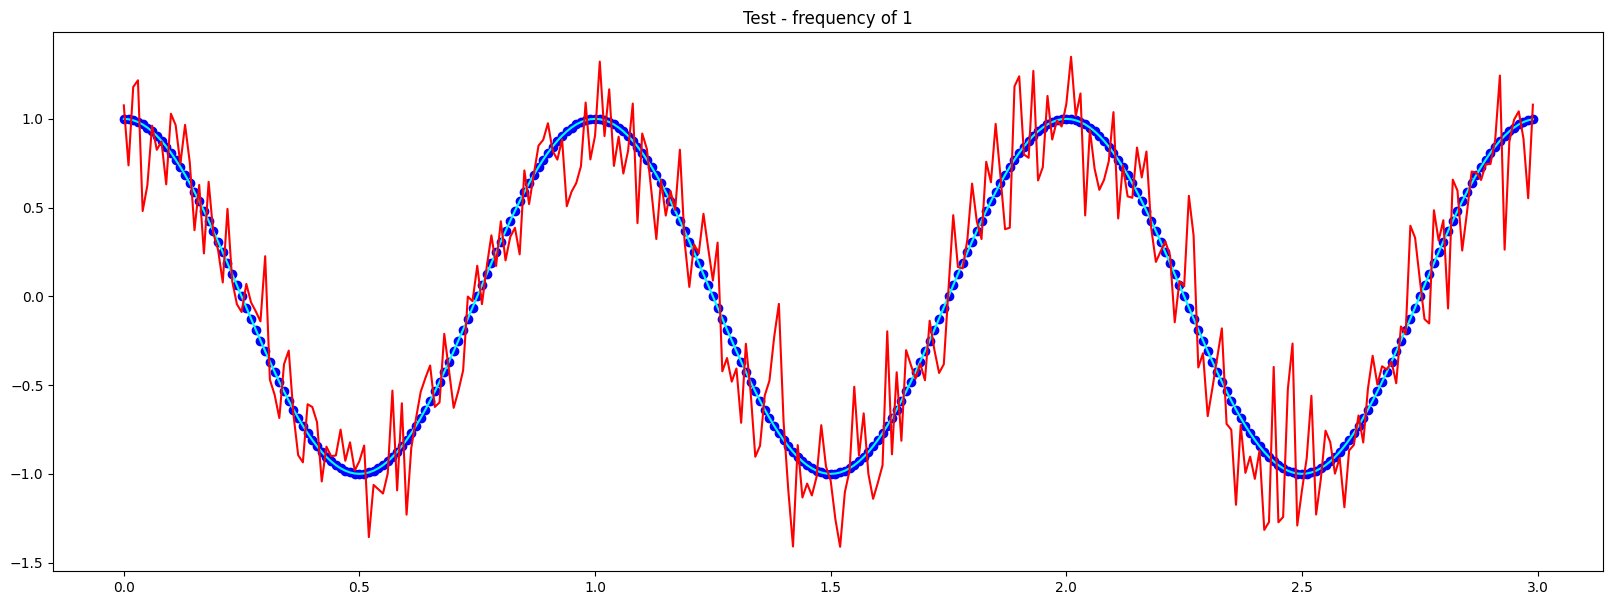

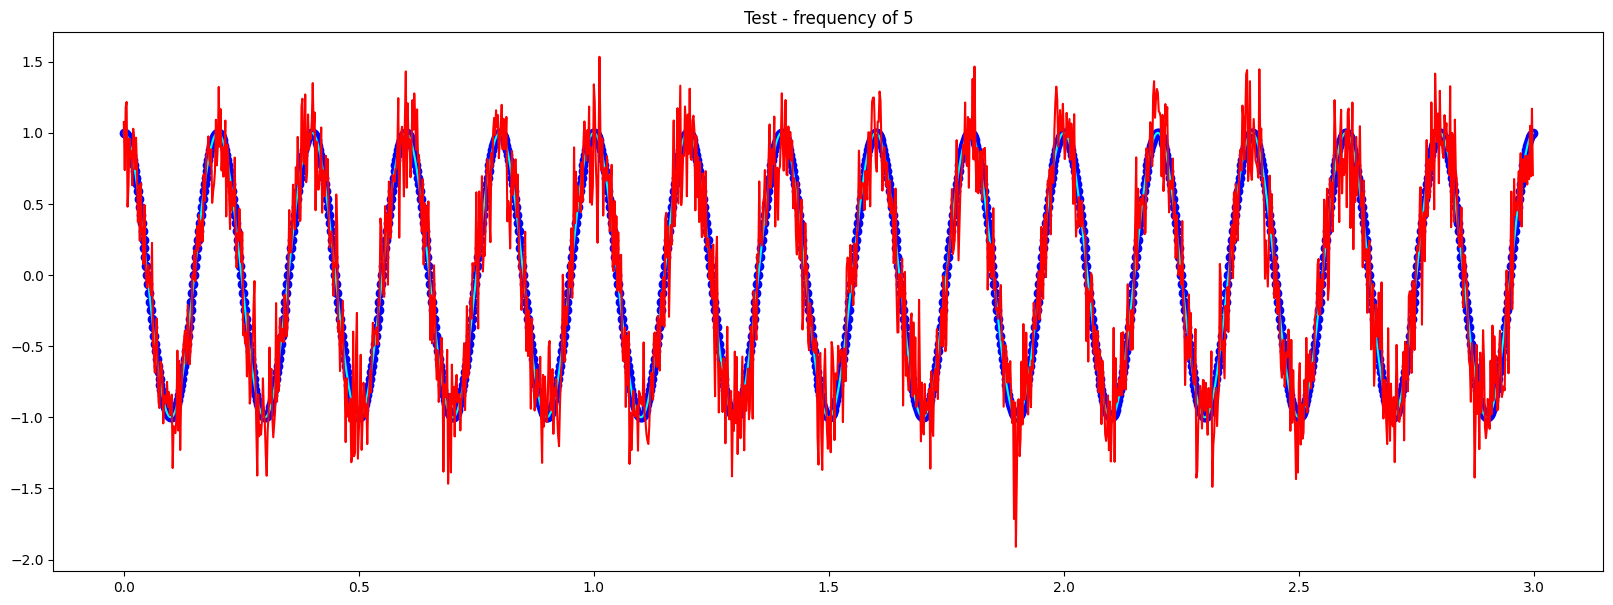

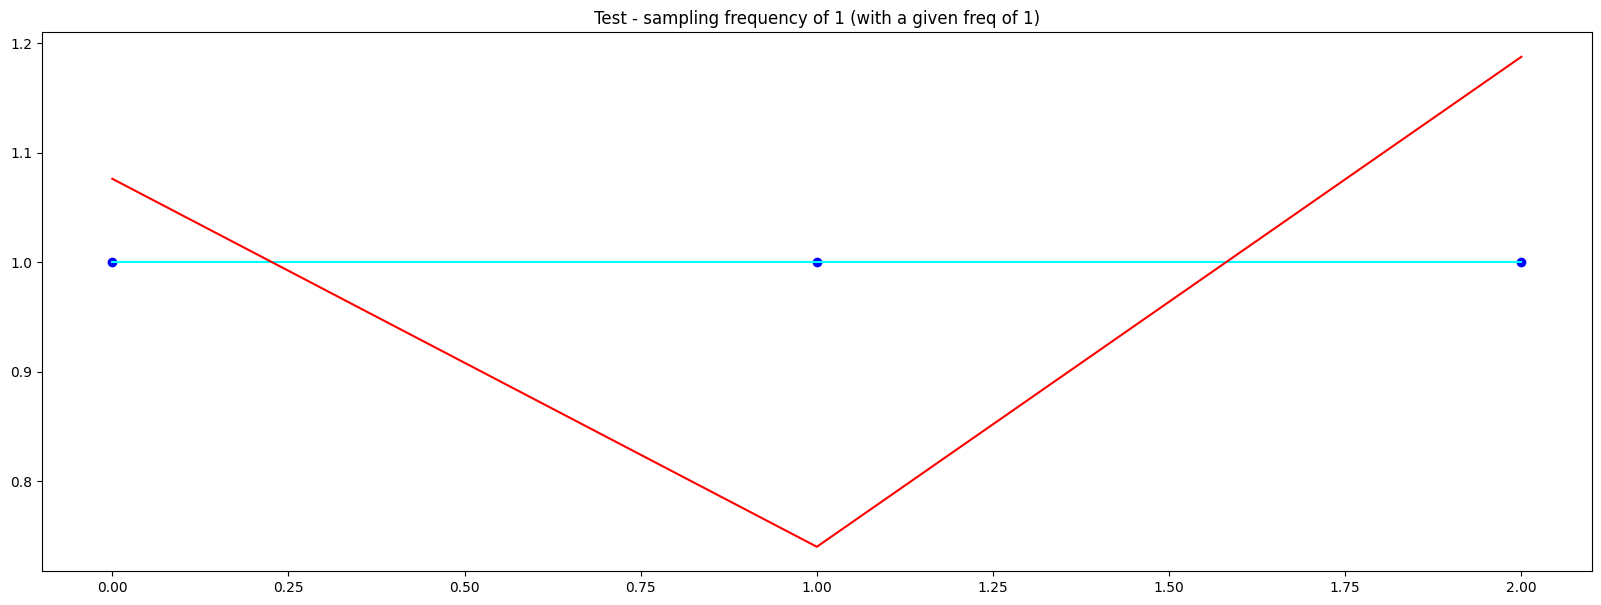

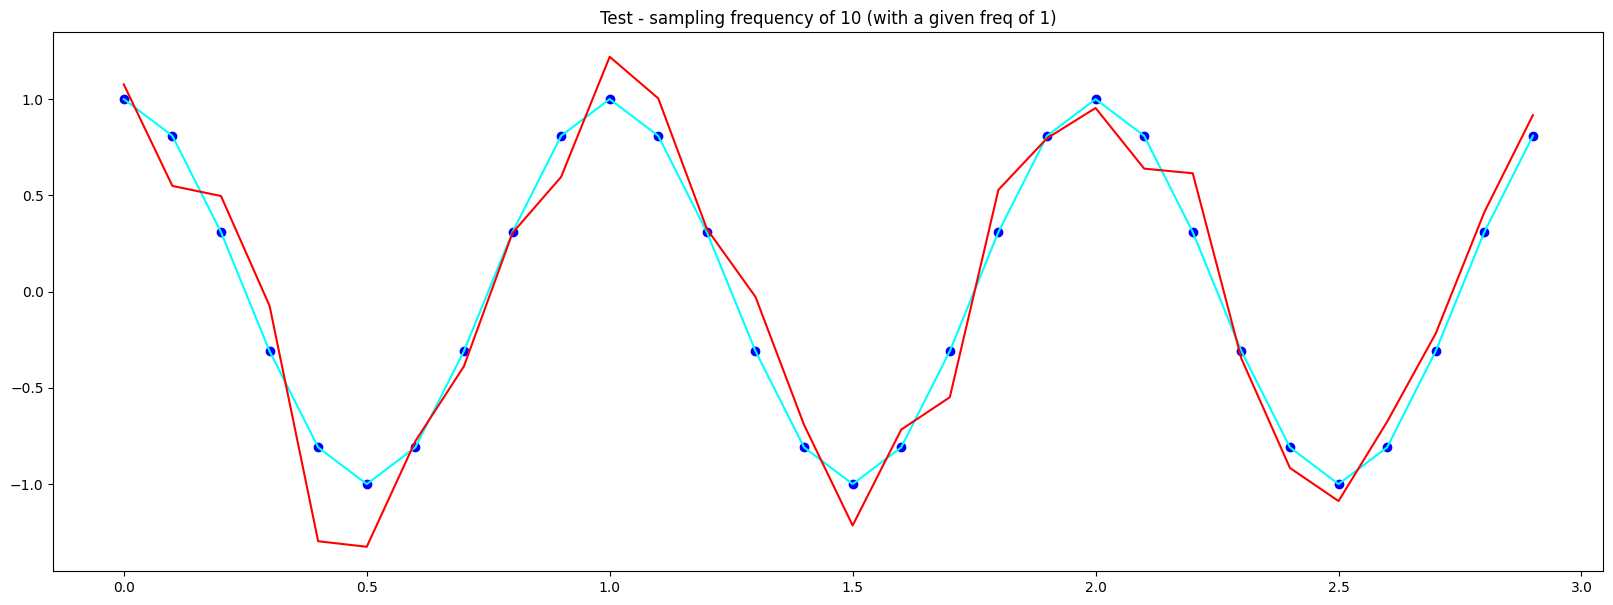

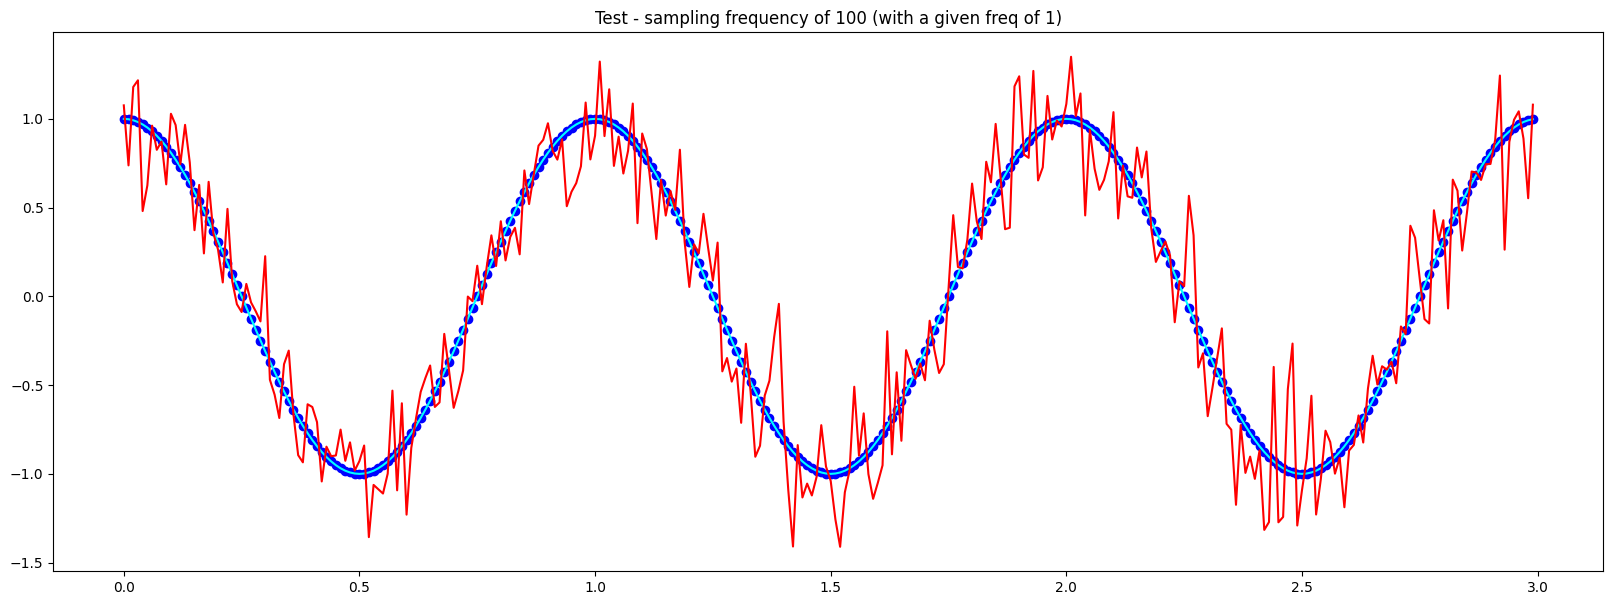

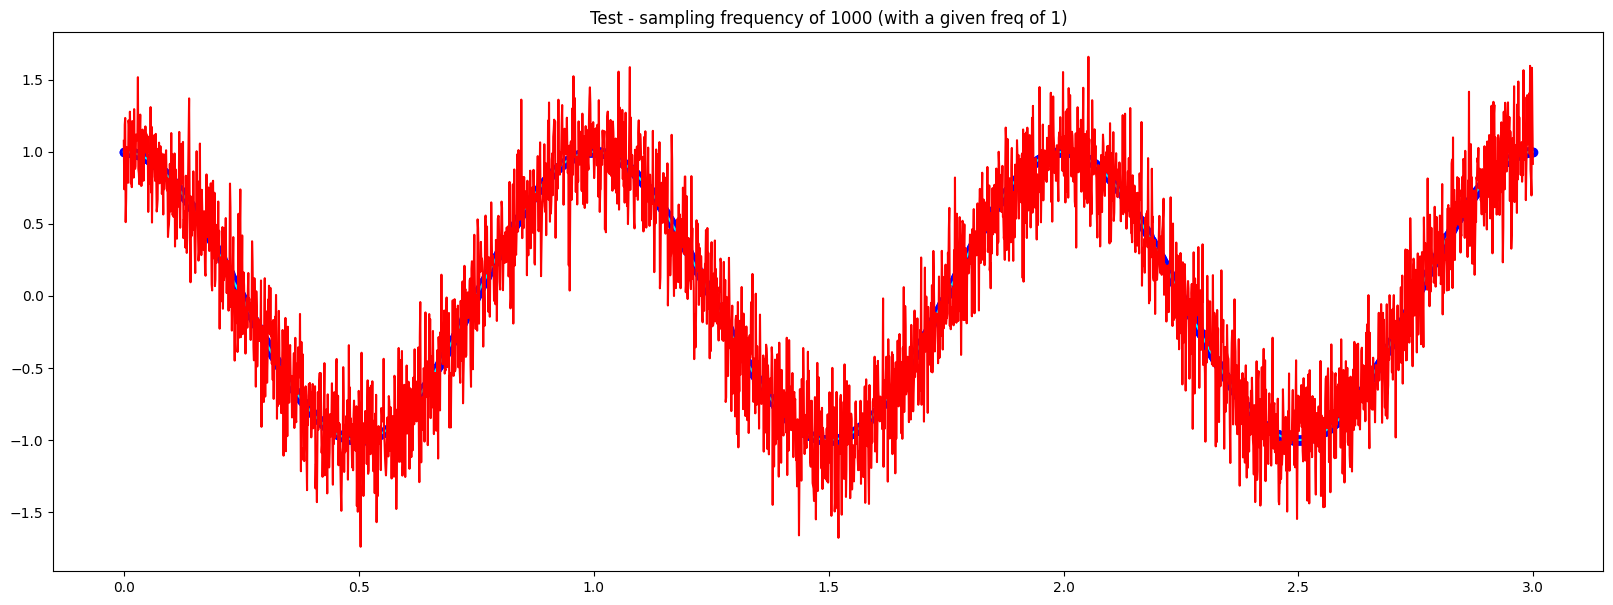

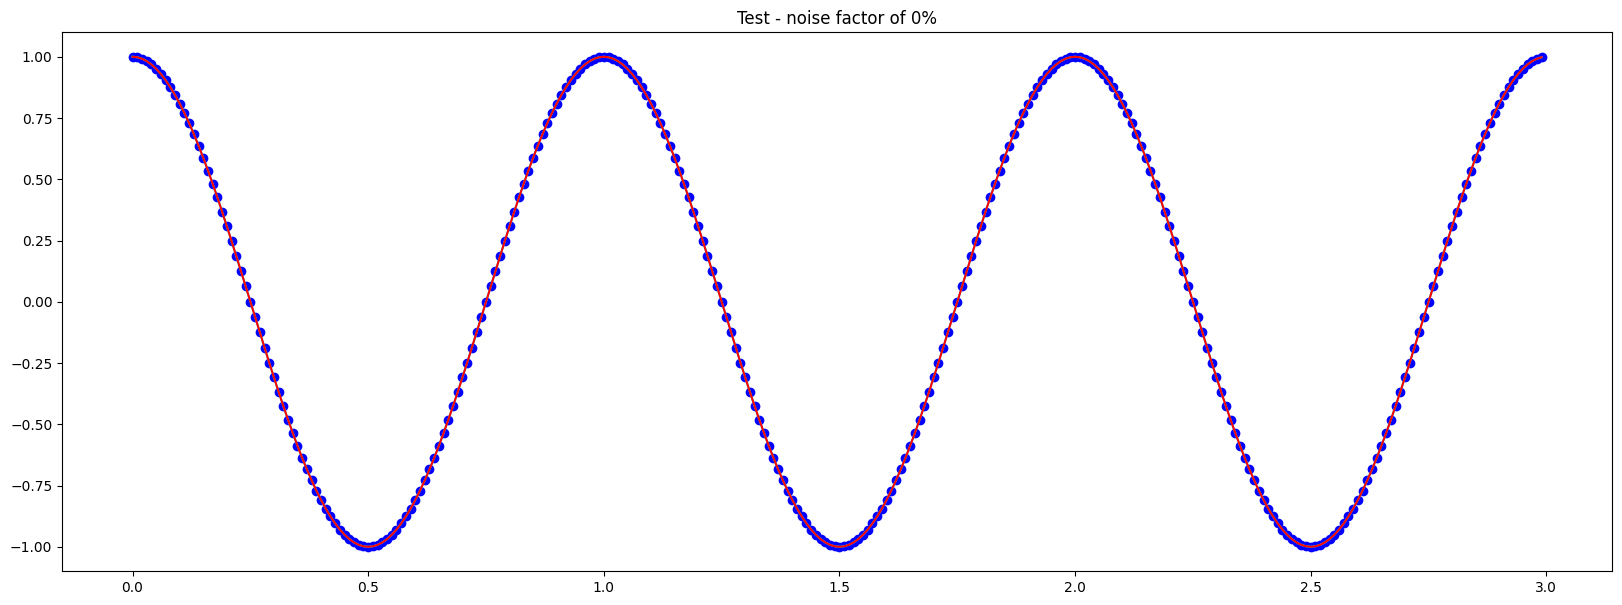

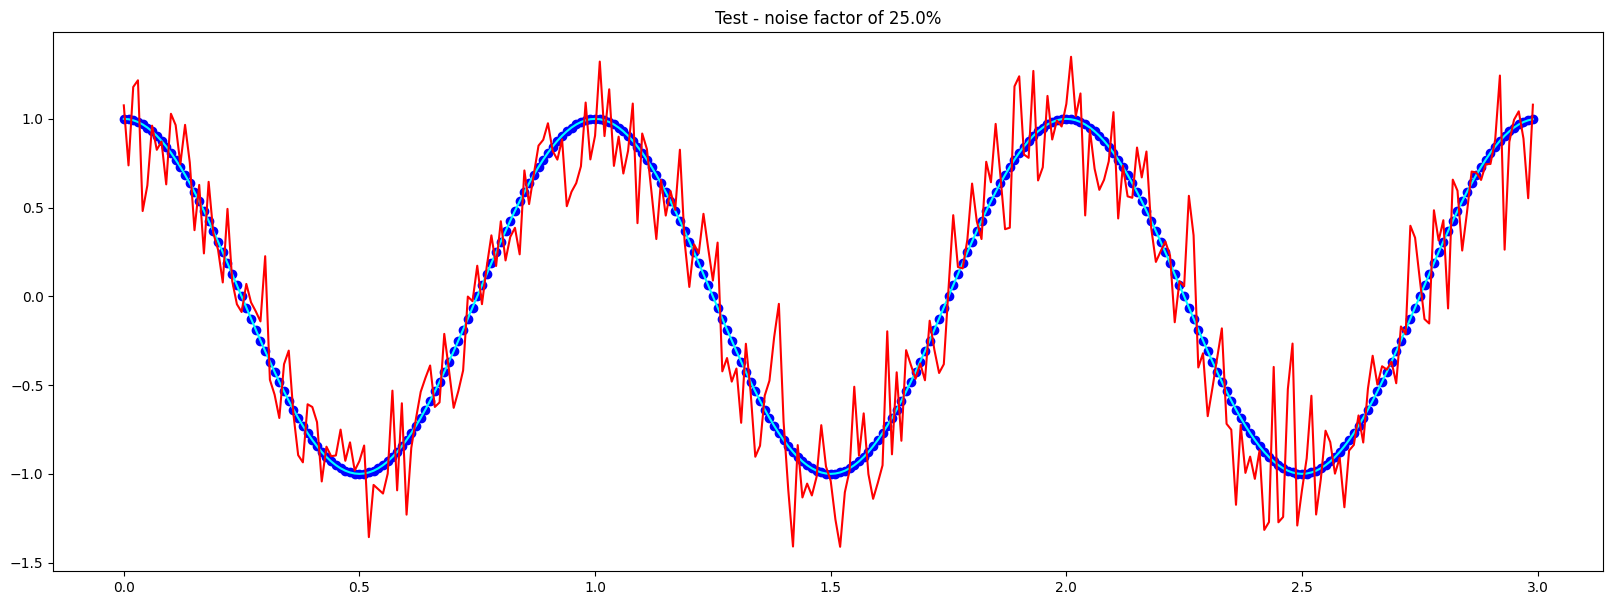

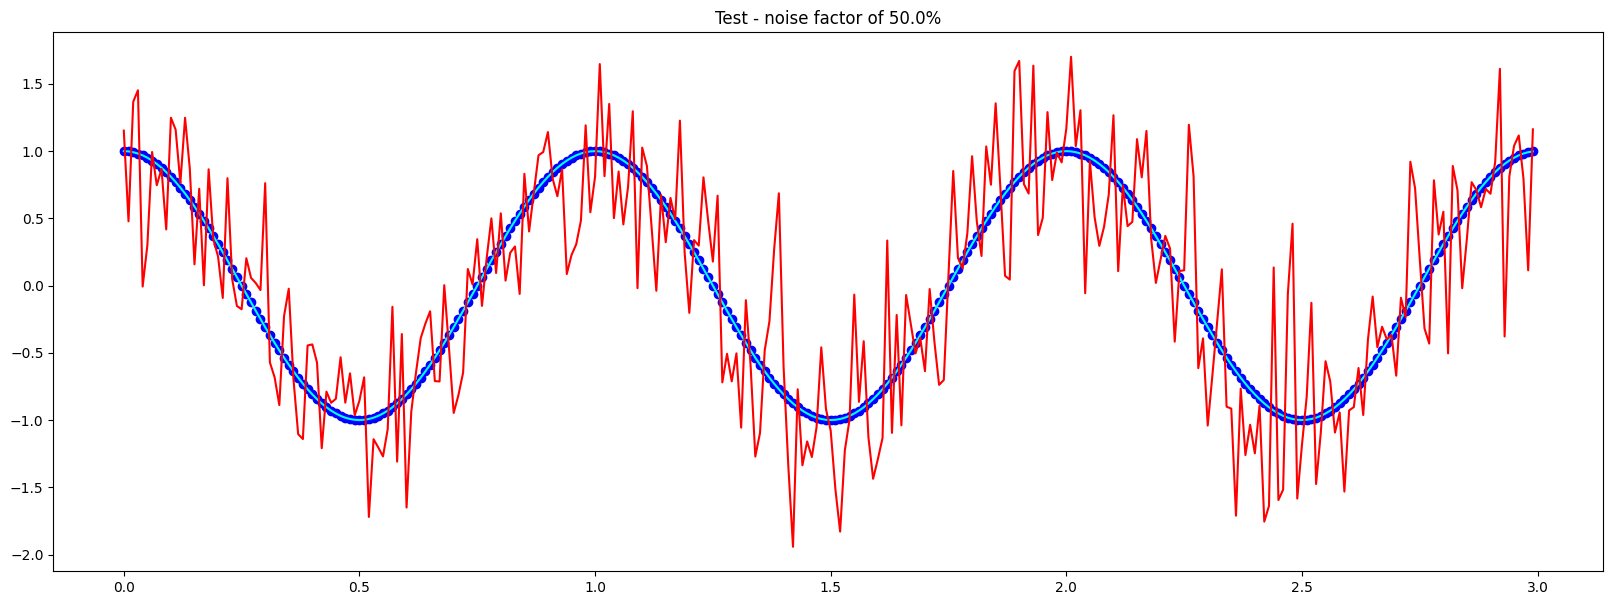

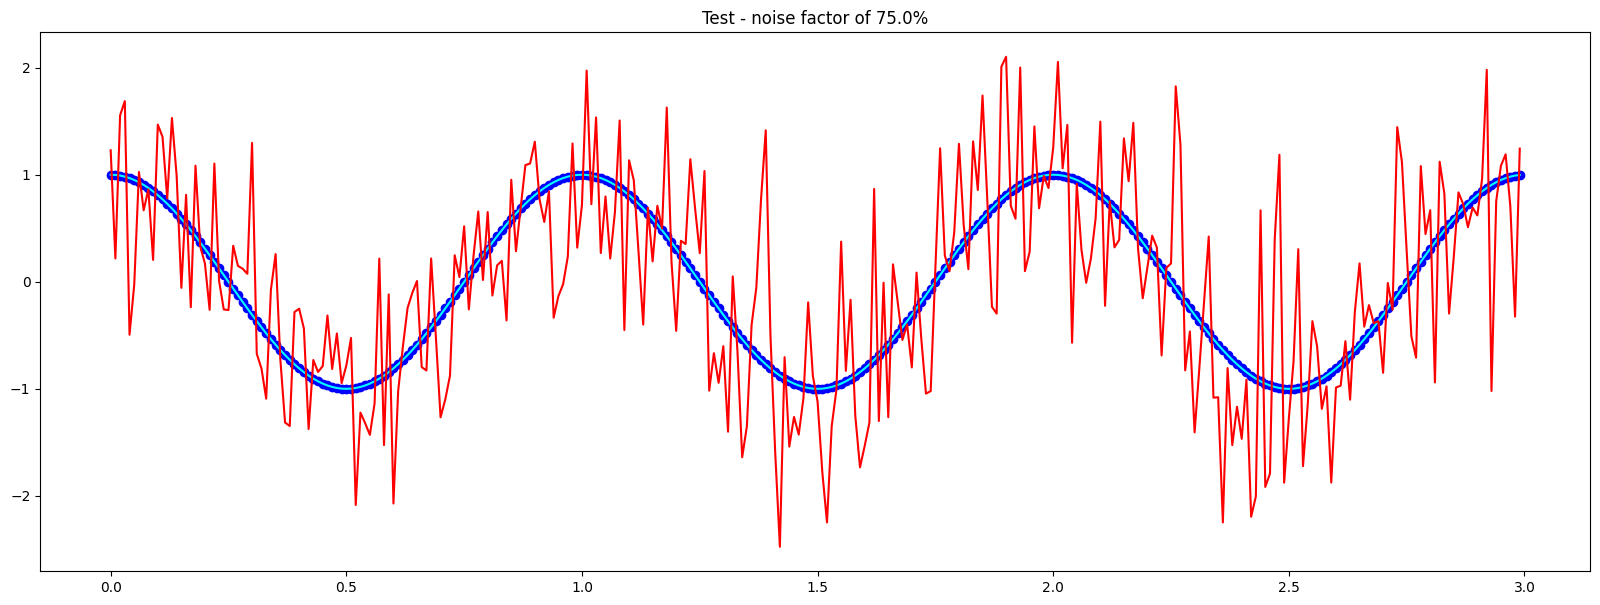

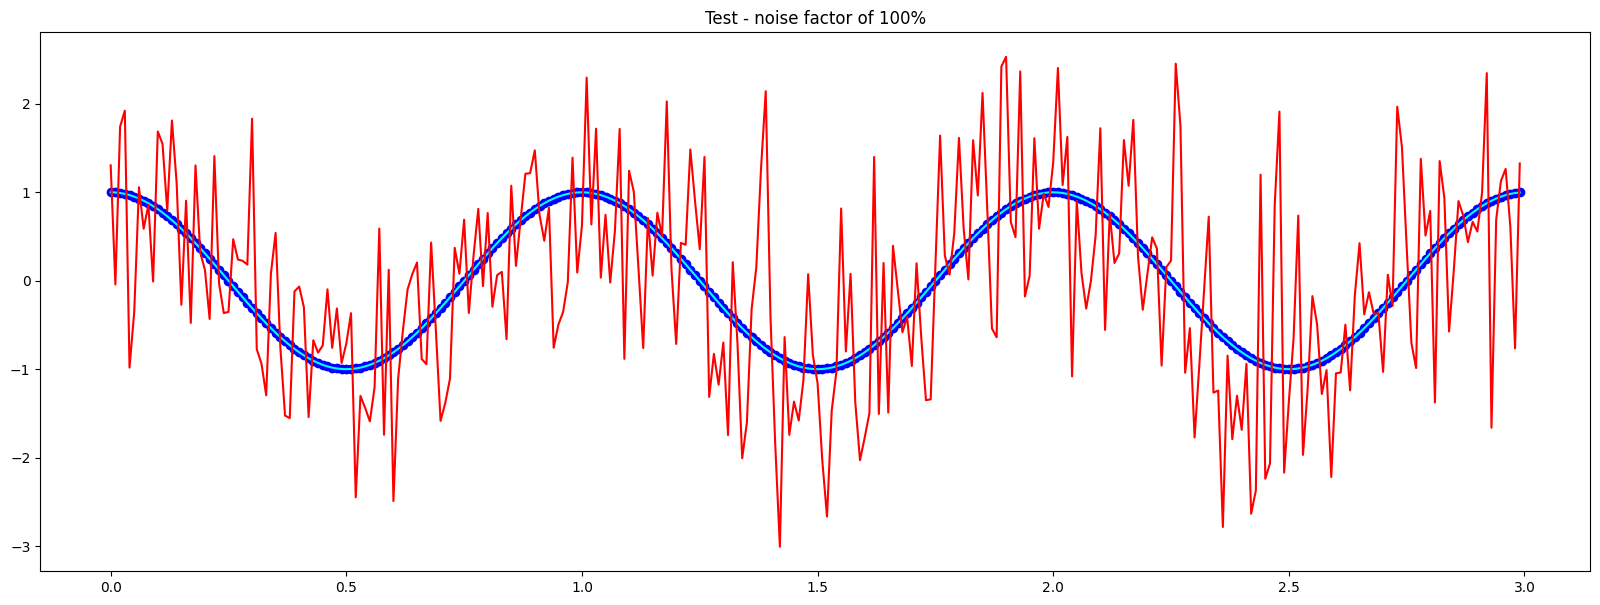

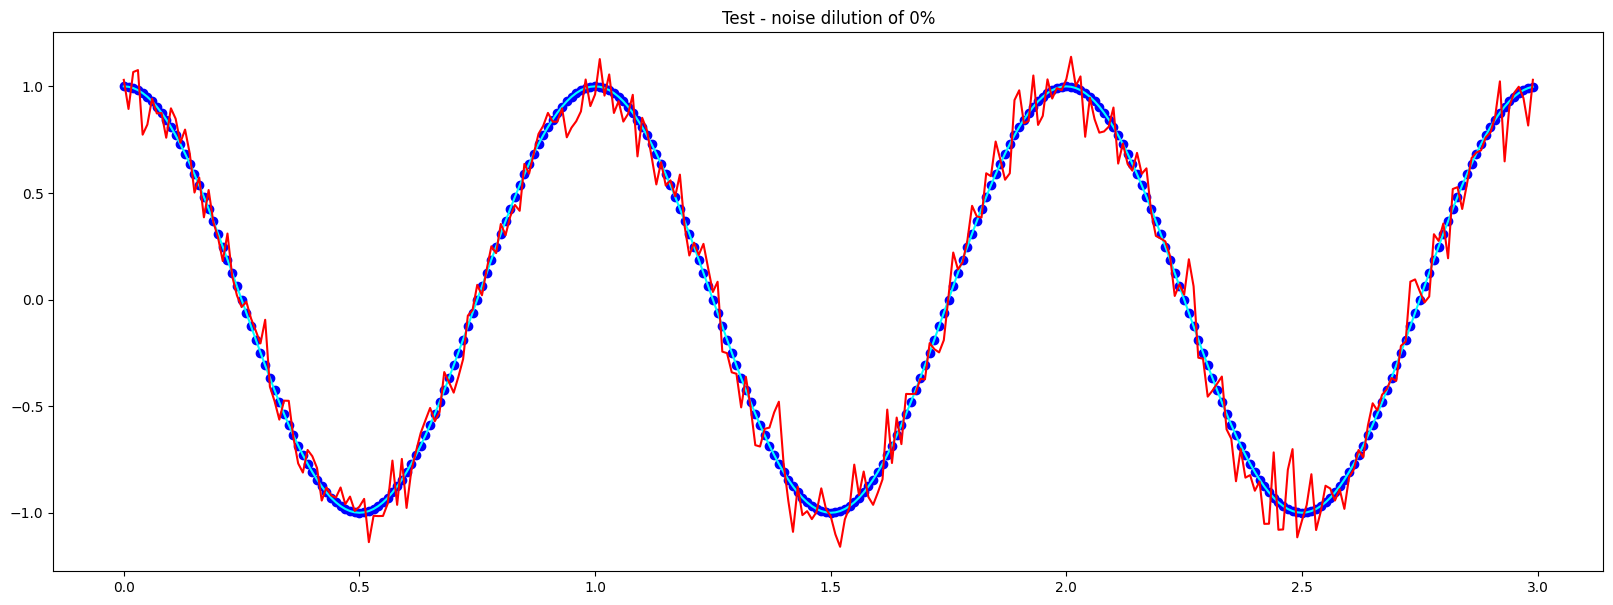

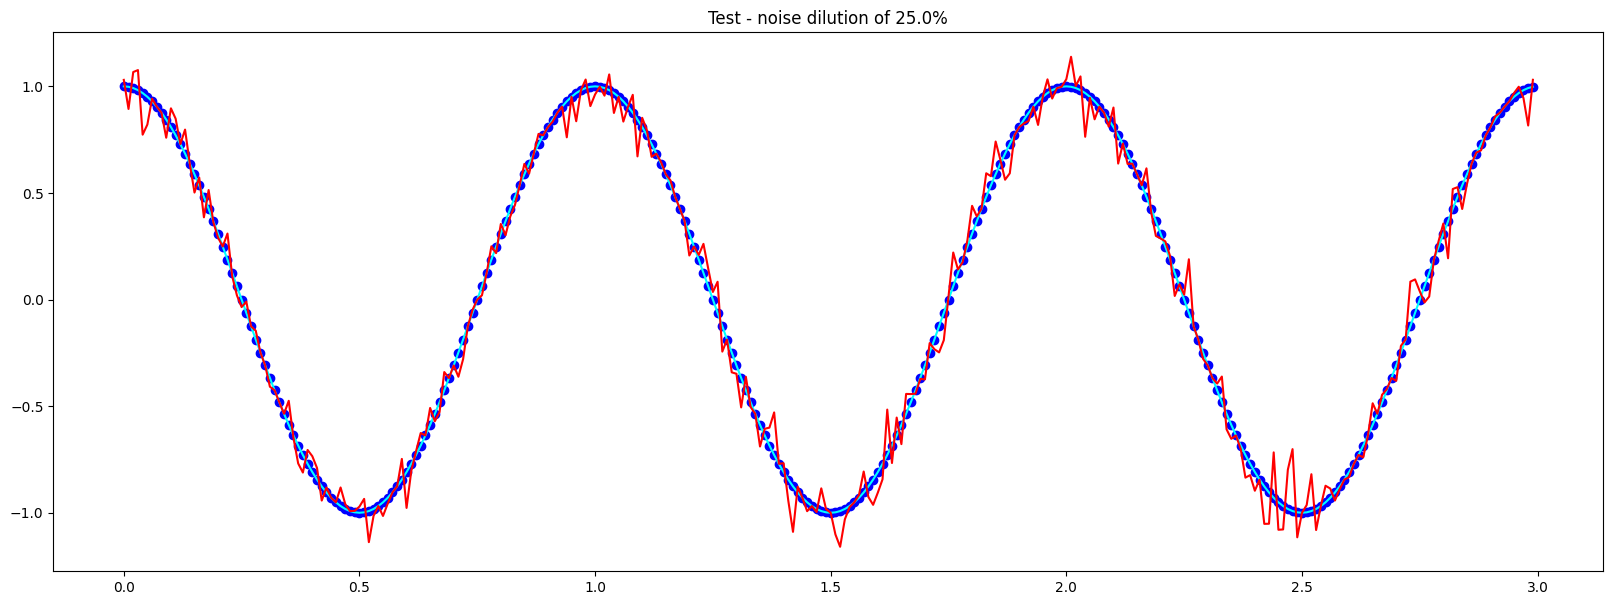

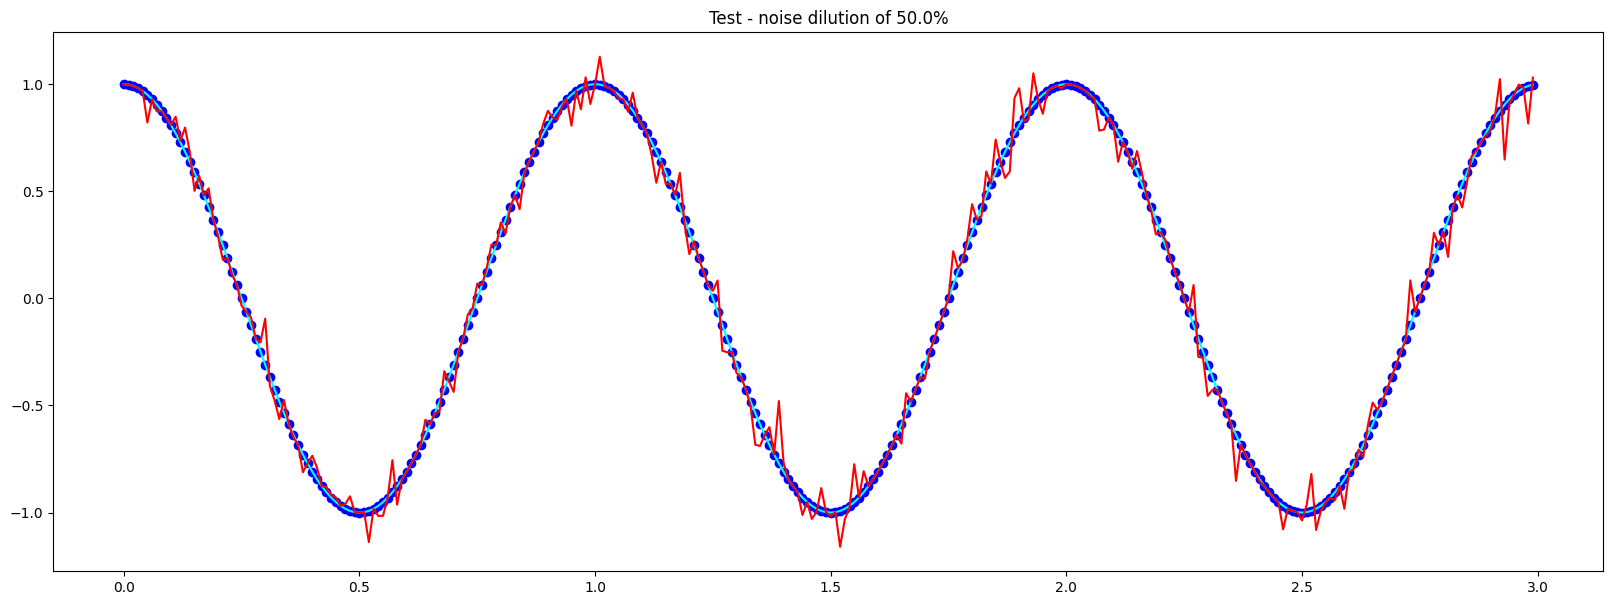

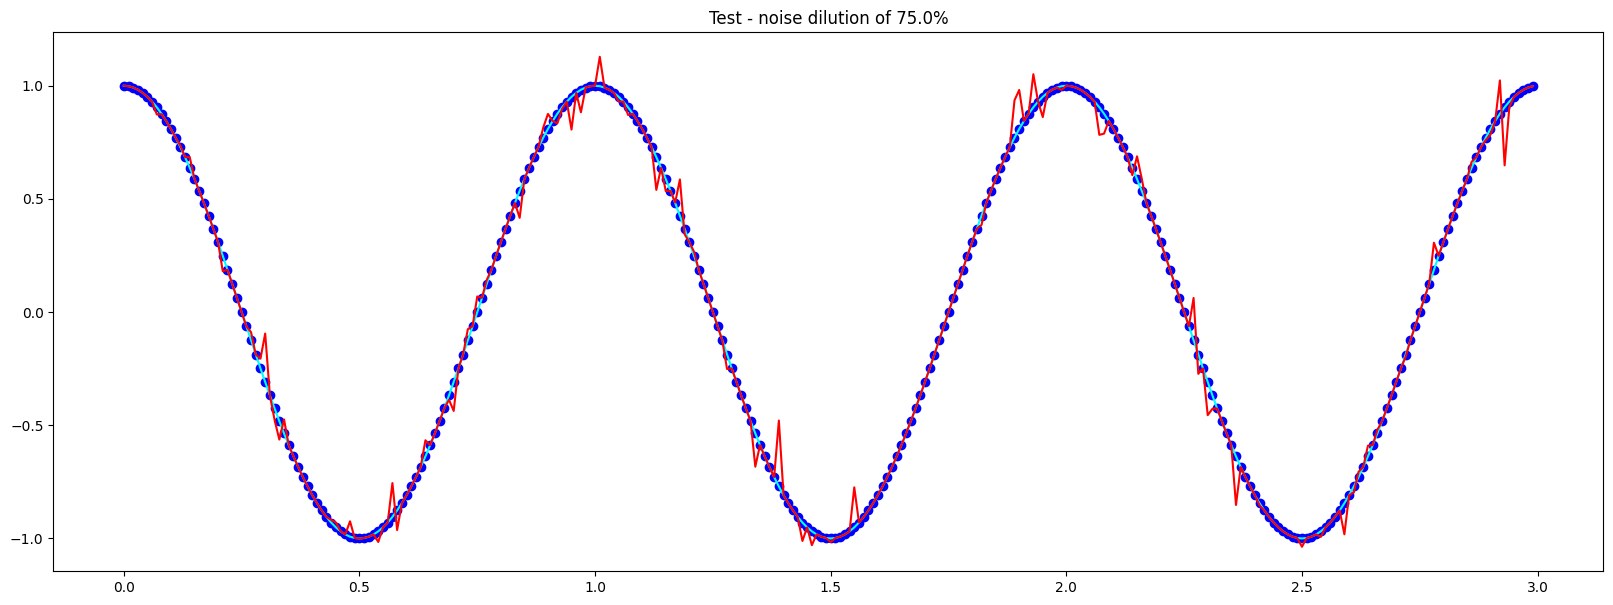

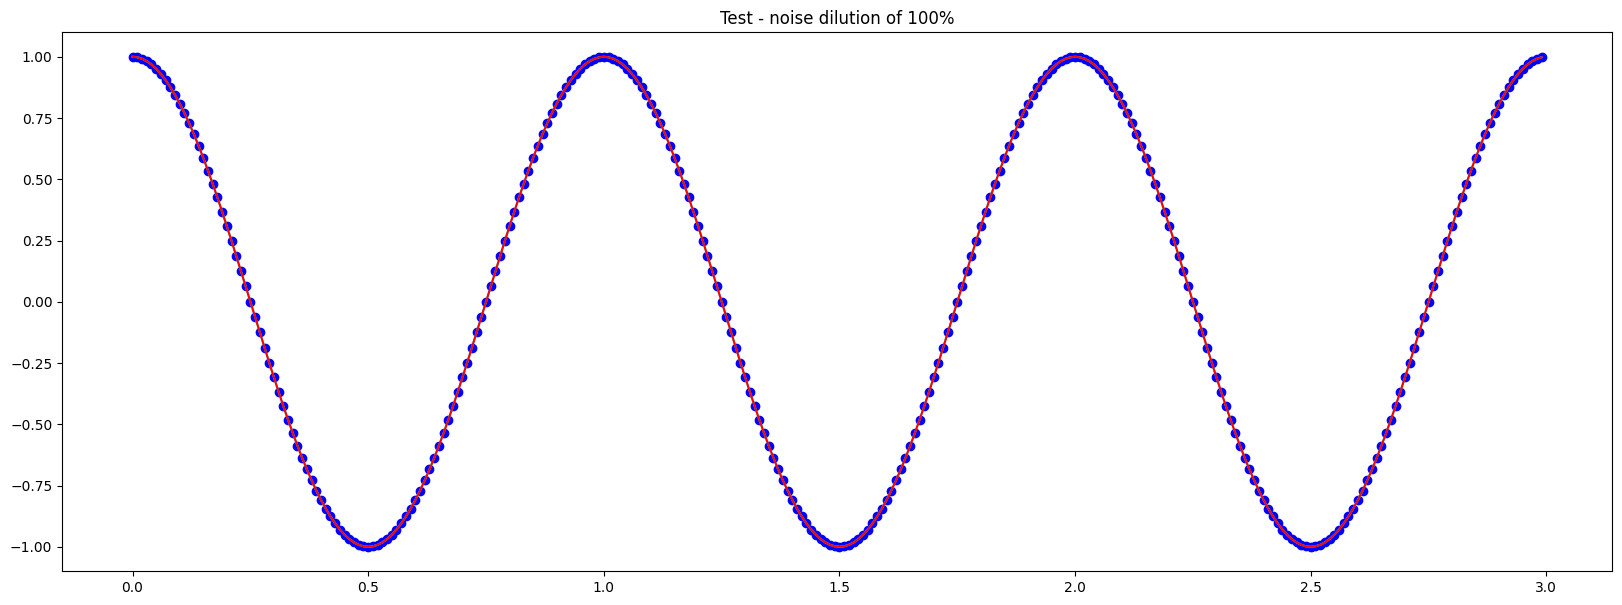

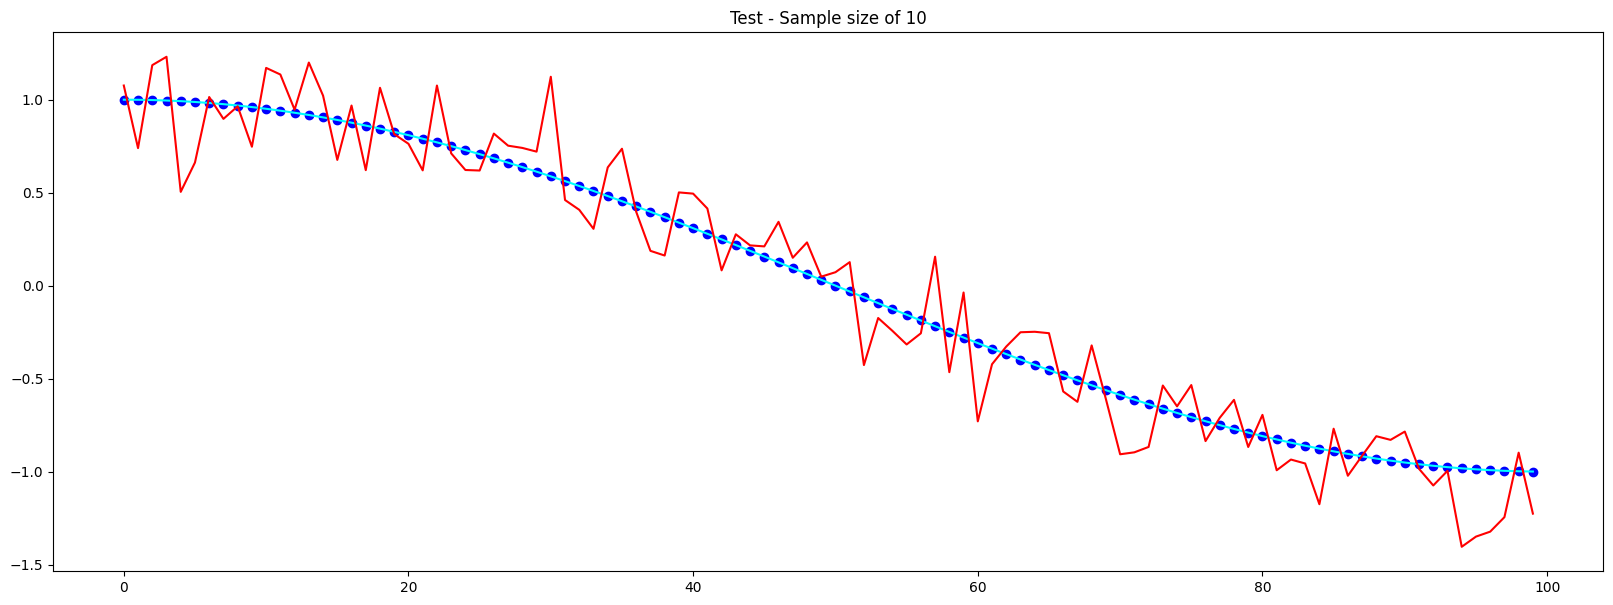

In [1]:
%run data.ipynb

#### Import libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Objectif

Dans ce notebook, l'objectif sera de réimplémenter un algorithme de type bandits.

Le contexte est le suivant: estimer l'action (la recommandation ?) la plus pertinente pour un profil utilisateur donné (représenté par la série temporelle de ses temps de visionnage) sur un site / une application de contenu long (ex. Youtube, Netflix, Prime Video, ...).

Pour entrainer l'algorithme, nous avons besoin de classifier des profils d'utilisateurs. Pour ce faire, d'après l'article [A global averaging method for dynamic time warping,
with applications to clustering](https://www.researchgate.net/publication/220601732_A_global_averaging_method_for_dynamic_time_warping_with_applications_to_clustering) (1), une mesure de similitude pertinente appliquable à un algorithme de clustering tel que K-means ou K-medoïds dans le cas ou les données sont des séries temporelles est la mesure Dynamic Time Wrapping (DTW) et plus précisémment sa version DBA (DTW Barycenter Averaging).
Nous allons donc commencer par implémenter cette mesure.

### Implémentation de DBA

In [3]:
def deltamat(A, B, distance=None):
    if distance is None:
        distance = lambda a,b: np.sqrt((a - b)**2)

    result = []    
    for i in range(0, len(A)):
        line = []
        
        for j in range(0, len(B)):
            line.append(distance(A[i], B[j]))

        result.append(line)

    return result

In [4]:
def squared_dtwmat(A, B, deltamat):
    S = len(A)
    T = len(B)
    
    M = [[0 for ci in range(0, T)] for li in range (0, S)]
    
    M[0][0] = (deltamat[0][0], -1)

    for i in range(1, S):
        M[i][0] = (
            M[i-1][0][0] + deltamat[i][0],
            2
        )

    for j in range(1, T):
        M[0][j] = (
            M[0][j-1][0] + deltamat[0][j],
            1
        )

    for i in range(1, S):
        for j in range(1, T):
            left = M[i][j-1][0]
            top = M[i-1][j][0]
            diagonal = M[i-1][j-1][0]
            
            min_cost = 0
            path = 0
            
            if diagonal <= left:
                if diagonal <= top:
                    min_cost = diagonal
                    path = 0
                else:
                    min_cost = top
                    path = 2
            else:
                if left <= top:
                    min_cost = left
                    path = 1
                else:
                    min_cost = top
                    path = 2
            
            M[i][j] = (
                min_cost + deltamat[i][j],
                path
            )

    return M

In [5]:
def dwtmat(A, B, deltamat):
    squared_dwt_mat = squared_dwtmat(A, B, deltamat)
    return map(lambda line: map(lambda V: (V[0]*V[0], V[1]), line), squared_dwt_mat)

In [6]:
def dba(
    series,
    itern=10,
    distance=None,
    max_index_sample_size=50
):
    N = len(series)
    maxlength = np.array(map(len, series)).max()

    # Search for initial center:
    medoid_search_indices = range(0, N)
    if N > max_index_sample_size:
        medoid_search_indices = np.random.choice(medoid_search_indices, max_index_sample_size, replace=False)

    medoid_index = -1
    best_ss = float('inf')
    for medoid_index_candidate in medoid_search_indices:
        candidate = series[medoid_index_candidate]
        
        ss = sum(map(
            lambda S: squared_dtwmat(candidate, S, deltamat(candidate, S))[-1][-1][0],
            series
        ))

        if medoid_index == -1 or ss < best_ss:
            best_ss = ss
            medoid_index = medoid_index_candidate

    center = series[medoid_index]

    #
    
    path2direction = [(-1, -1), (0, -1), (-1, 0)]
    for iterindex in range(0,itern):
        center_len = len(center)
        new_center = [0 for i in range(0, center_len)]
        new_center_value_count = [0 for i in range(0, center_len)]

        for S in series:
            S_len = len(S)
            delta_mat = deltamat(center, S)

            squared_dtw_mat = squared_dtwmat(center, S, delta_mat)

            i = center_len-1
            j = S_len-1

            while squared_dtw_mat[i][j][1] != -1:
                new_center[i] = new_center[i] + S[j]
                new_center_value_count[i] = new_center_value_count[i] + 1

                move = path2direction[squared_dtw_mat[i][j][1]]

                i += move[0]
                j += move[1]

            assert (i == 0 and j == 0)

            new_center[i] = new_center[i] + S[j]
            new_center_value_count[i] = new_center_value_count[i] + 1

        new_center = [new_center[i] / new_center_value_count[i] for i in range(0, center_len)]
        
        center = new_center

    return center

In [7]:
#generating synthetic data
n_series = 20
length = 200
series = list()
padding_length=30
indices = range(0, length-padding_length)
main_profile_gen = np.array(list(map(lambda j: np.sin(2*np.pi*j/len(indices)),indices)))
for i in range(0,n_series):
        n_pad_left = np.random.randint(0,padding_length)
        #adding zero at the start or at the end to shif the profile
        series_i = np.pad(main_profile_gen,(n_pad_left,padding_length-n_pad_left),mode='constant',constant_values=0)
        #randomize a bit
        series_i = list(map(lambda j:np.random.normal(0,0.03)+j,series_i))
        assert(len(series_i)==length)
        series.append(series_i)
series = np.array(series)

<Figure size 640x480 with 0 Axes>

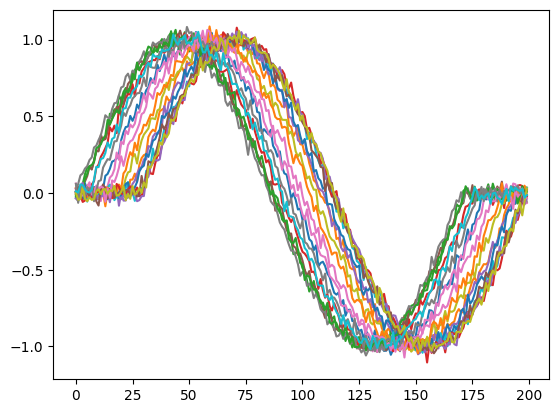

<Figure size 640x480 with 0 Axes>

In [8]:
#plotting the synthetic data
for s in series:
  plt.plot(range(0,length), s)
plt.draw()
plt.figure()

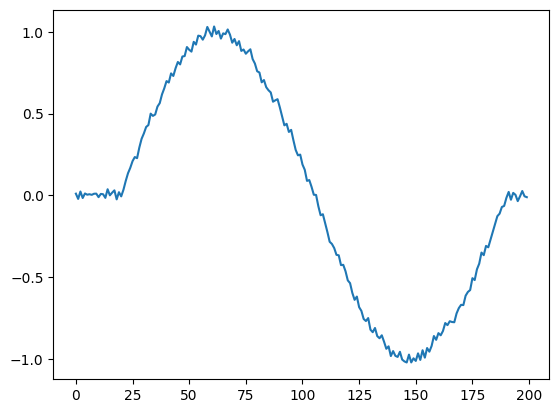

In [9]:
#calculating average series with DBA
average_series = dba(series)

#plotting the average series
plt.figure()
plt.plot(range(0,len(average_series)), average_series)
plt.show()


### Clustering (online/offline) des séries temporelles basé sur DBA

In [167]:
def Kverage(
    X,
    K,
    distance,
    centroidCalculator,
    online=False,
    baseSampleSize=None,
    errorThreshold=1e-4,
    maxIterationCount=40,
    random_state=None
):
    rng = np.random.default_rng(random_state)
    
    if baseSampleSize is None:
        baseSampleSize = K

    assert baseSampleSize >= K

    #
    
    previous_klassCentroids = [None for _ in range(K)]
    
    if online:
        klassCentroids = X[:K]
        sample = X[:baseSampleSize]
    else:
        klassCentroids = [X[i] for i in rng.choice(range(len(X)), size=K, replace=False)]
        sample = X

    #
    
    hasConverged = False
    labels = None
    iterationIndex = 0
    
    while (
        (
            online
            or (
                not hasConverged
                and iterationIndex < maxIterationCount
            )
        )
        and (
            not online
            or (
                len(sample) < len(X)
            )
        )
    ):
        if online:
            sample.append(X[len(sample)])

        labels = []
        klassSets = [[] for _ in range(K)]
        
        for x in sample:
            dist2centroids = np.array([distance(x, centroid) for centroid in klassCentroids])
            klass = dist2centroids.argmin()
            labels.append(klass)
            klassSets[klass].append(x)

        # Recalculate centroids
        previous_klassCentroids = klassCentroids
        klassCentroids = [centroidCalculator(klassSets[klass]) for klass in range(K)]

        # Check convergence
        klassCentroidIndex = 0
        hasConverged = True
        while hasConverged and klassCentroidIndex < K:
            d = distance(klassCentroids[klassCentroidIndex], previous_klassCentroids[klassCentroidIndex])
            if np.abs(d) > errorThreshold:
                hasConverged = False
            
            klassCentroidIndex+=1

        #

        iterationIndex+=1

    #
    
    return (klassCentroids, labels, iterationIndex)

In [168]:
K = 6
colors = ["#00ff0044", "#964b0044", "#00fff044", "#0000ff44", "#ff00ff44", "#ff000044", "#ff800044"][:K]
training_df = pd.read_csv("../../data/housing.csv")[["MedInc", "Latitude", "Longitude"]]
training_df_sample = training_df.sample(frac=0.25)

def dist(p1, p2):
    delta = np.array(p1-p2)
    return (delta*delta).sum()

def centroidCalculator(klassSet):
    points = [np.array(p) for p in klassSet]

    centroid = np.zeros(points[0].shape)
    for p in points:
        centroid = centroid + p
    
    centroid = centroid / len(klassSet)
    return centroid

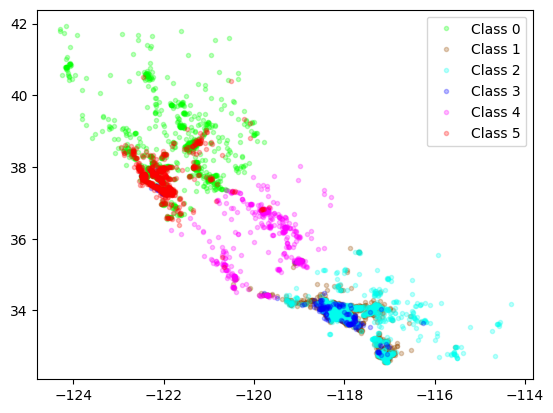

In [169]:
from sklearn.cluster import KMeans

model = KMeans(K, random_state=42)
model.fit(training_df_sample)

#

result_df = training_df_sample.copy()
result_df["cluster"] = model.labels_

#

for k in range(K):
    klassSet = result_df[result_df["cluster"] == k]
    
    plt.plot(klassSet["Longitude"], klassSet["Latitude"], ".", color=colors[k], label="Class " + str(k))

plt.legend()
plt.show()

21 [array([   7.4466168,   37.62212  , -122.02072  ]), array([   4.32881208,   37.81019187, -121.9551693 ]), array([   2.42118238,   38.603075  , -121.877225  ]), array([   6.51696963,   33.82108183, -118.01538141]), array([   3.09018188,   33.81905248, -117.83858601]), array([   2.75717438,   35.96116854, -119.78026966])]


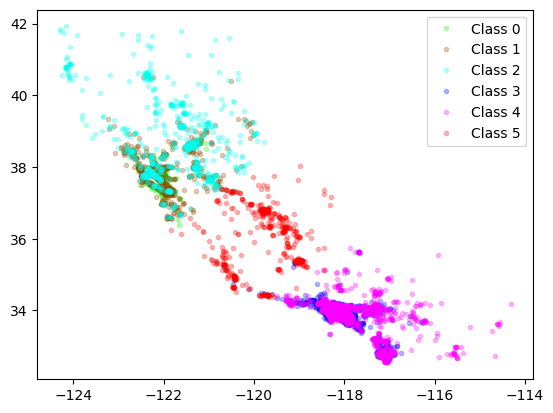

In [170]:
X = [np.array(p) for p in training_df_sample.values.tolist()]

centroids, labels, iterationCount = Kverage(
    X,
    K,
    dist,
    centroidCalculator,
    random_state=42
)

print(iterationCount, centroids)

#

result_df = training_df_sample.copy()
result_df["cluster"] = labels

#

for k in range(K):
    klassSet = result_df[result_df["cluster"] == k]
    
    plt.plot(klassSet["Longitude"], klassSet["Latitude"], ".", color=colors[k], label="Class " + str(k))

plt.legend()
plt.show()

5154 [array([  10.91723504,   34.92017094, -119.26598291]), array([   2.71751343,   35.98488426, -119.78099537]), array([   5.45522313,   33.81151452, -117.98711618]), array([   5.3948203 ,   37.70655914, -121.99711022]), array([   2.80013244,   38.38585198, -121.87914802]), array([   2.83835841,   33.82635267, -117.82530155])]
[5, 3, 5, 3, 4, 5, 5, 4, 4, 2, 5, 2, 5, 5, 3, 4, 2, 3, 4, 1, 5, 5, 4, 4, 1, 5, 3, 3, 2, 3, 1, 1, 4, 5, 2, 5, 1, 4, 4, 5, 5, 5, 4, 5, 2, 5, 4, 2, 5, 3, 2, 5, 1, 5, 3, 0, 5, 2, 3, 4, 2, 0, 2, 5, 5, 4, 4, 4, 5, 5, 4, 4, 2, 3, 5, 1, 4, 0, 0, 1, 5, 5, 2, 4, 5, 4, 3, 4, 2, 1, 2, 5, 1, 3, 0, 5, 2, 2, 5, 4, 5, 4, 5, 5, 3, 1, 3, 5, 3, 5, 3, 1, 4, 2, 2, 4, 5, 5, 4, 4, 4, 2, 1, 5, 4, 4, 3, 3, 2, 4, 0, 5, 4, 2, 5, 1, 5, 5, 4, 4, 5, 3, 5, 5, 4, 2, 1, 4, 2, 2, 4, 4, 4, 1, 3, 5, 3, 5, 5, 4, 3, 4, 4, 3, 5, 1, 2, 5, 5, 2, 3, 0, 1, 5, 4, 2, 4, 5, 4, 2, 1, 2, 1, 3, 3, 0, 4, 5, 4, 4, 4, 1, 5, 3, 1, 3, 3, 2, 5, 4, 5, 2, 4, 5, 5, 5, 4, 5, 3, 5, 2, 5, 4, 3, 2, 4, 4, 3, 5, 4, 5, 3, 2, 

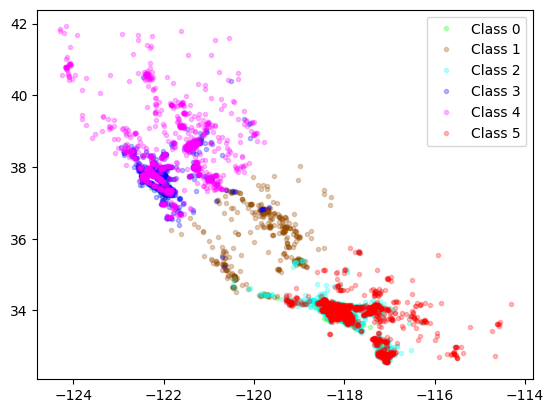

In [171]:
X = [np.array(p) for p in training_df_sample.values.tolist()]

centroids, labels, iterationCount = Kverage(
    X,
    K,
    dist,
    centroidCalculator,
    online=True,
    random_state=42
)

print(iterationCount, centroids)

#

print(labels)
result_df = training_df_sample.copy()
result_df["cluster"] = labels

#

for k in range(K):
    klassSet = result_df[result_df["cluster"] == k]
    
    plt.plot(klassSet["Longitude"], klassSet["Latitude"], ".", color=colors[k], label="Class " + str(k))

plt.legend()
plt.show()